# Preguntas clave para tomar decisiones basadas en datos
9 - 16

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../movies_2026.csv', encoding='latin-1')

### 9. ¿Es posible que la cantidad de hombres y mujeres en el reparto influya en la popularidad y los ingresos de las películas?

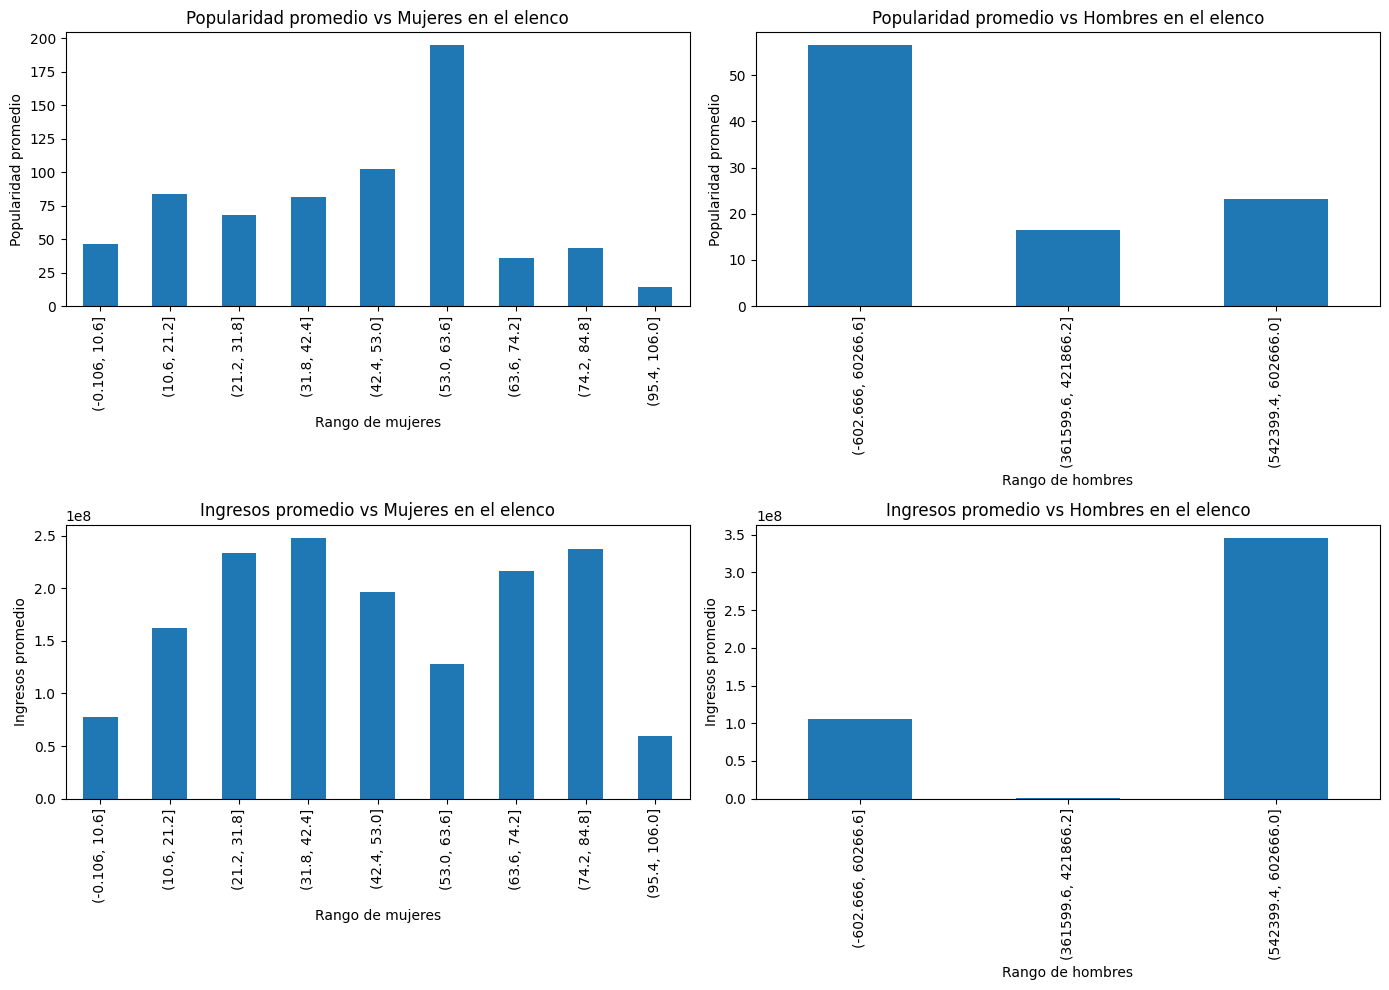

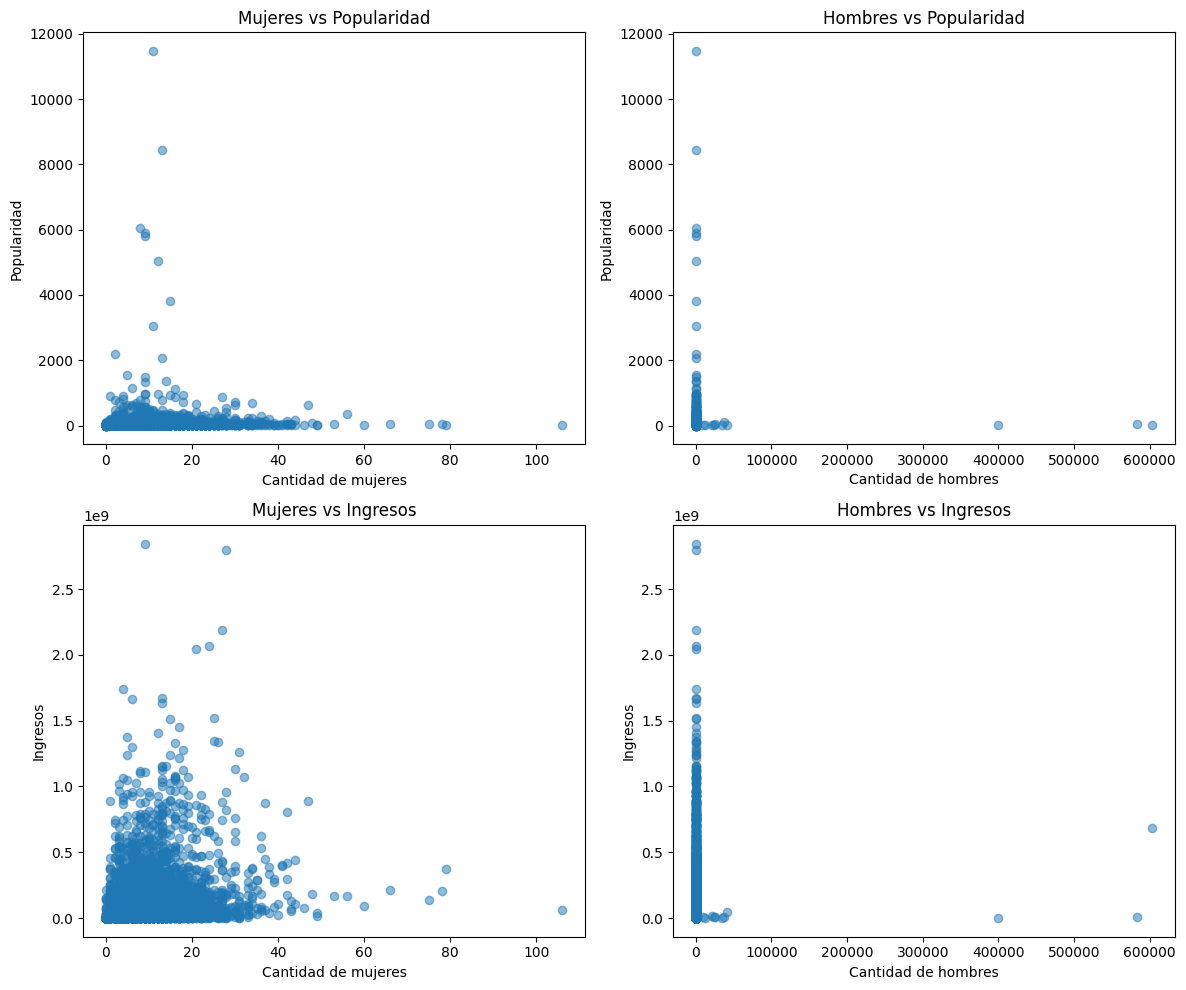

In [2]:
#castWomenAmount, castMenAmount, renvenue, popularity 

df9 = df[['castWomenAmount', 'castMenAmount', 'popularity', 'revenue']].copy()
df9 = df9.dropna()

# Eliminar películas sin ingresos reportados
df9 = df9[df9['revenue'] > 0]


bins_women = pd.cut(df9['castWomenAmount'], bins=10)
bins_men   = pd.cut(df9['castMenAmount'], bins=10)

avg_pop_women = df9.groupby(bins_women)['popularity'].mean()
avg_pop_men   = df9.groupby(bins_men)['popularity'].mean()

avg_rev_women = df9.groupby(bins_women)['revenue'].mean()
avg_rev_men   = df9.groupby(bins_men)['revenue'].mean()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Mujeres vs Popularidad
avg_pop_women.plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Popularidad promedio vs Mujeres en el elenco')
axes[0,0].set_xlabel('Rango de mujeres')
axes[0,0].set_ylabel('Popularidad promedio')

# Hombres vs Popularidad
avg_pop_men.plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Popularidad promedio vs Hombres en el elenco')
axes[0,1].set_xlabel('Rango de hombres')
axes[0,1].set_ylabel('Popularidad promedio')

# Mujeres vs Ingresos
avg_rev_women.plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Ingresos promedio vs Mujeres en el elenco')
axes[1,0].set_xlabel('Rango de mujeres')
axes[1,0].set_ylabel('Ingresos promedio')

# Hombres vs Ingresos
avg_rev_men.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Ingresos promedio vs Hombres en el elenco')
axes[1,1].set_xlabel('Rango de hombres')
axes[1,1].set_ylabel('Ingresos promedio')

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Mujeres vs Popularidad
axes[0, 0].scatter(df9['castWomenAmount'], df9['popularity'], alpha=0.5)
axes[0, 0].set_title('Mujeres vs Popularidad')
axes[0, 0].set_xlabel('Cantidad de mujeres')
axes[0, 0].set_ylabel('Popularidad')

# Hombres vs Popularidad
axes[0, 1].scatter(df9['castMenAmount'], df9['popularity'], alpha=0.5)
axes[0, 1].set_title('Hombres vs Popularidad')
axes[0, 1].set_xlabel('Cantidad de hombres')
axes[0, 1].set_ylabel('Popularidad')

# Mujeres vs Ingresos
axes[1, 0].scatter(df9['castWomenAmount'], df9['revenue'], alpha=0.5)
axes[1, 0].set_title('Mujeres vs Ingresos')
axes[1, 0].set_xlabel('Cantidad de mujeres')
axes[1, 0].set_ylabel('Ingresos')

# Hombres vs Ingresos
axes[1, 1].scatter(df9['castMenAmount'], df9['revenue'], alpha=0.5)
axes[1, 1].set_title('Hombres vs Ingresos')
axes[1, 1].set_xlabel('Cantidad de hombres')
axes[1, 1].set_ylabel('Ingresos')

plt.tight_layout()
plt.show()


### Discusion de resultados
Se puede observar que existe una ligera correlación con la cantidad de mujeres en el reparto y la popularidad e ingresos de las películas. Ya que en las películas con mayor popularidad e ingresos, la cantidad de mujeres en el reparto es de mayor tamaño en comparación con las de hombres. Sin embargo, esta correlación no es muy fuerte y debido a los datos atípicos presentes en el conjunto de datos, no es posible visualizar de forma clara alguna relación viendola en un grafico de dispersión.

Sin embargo, para facilitar la interpretación de los resultados, se agruparon las películas en rangos según la cantidad de hombres y mujeres en el elenco y se calculó la popularidad e ingresos promedio por rango.

Los resultados muestran que no existe una tendencia clara que indique que un mayor número de hombres o mujeres en el reparto esté asociado con un incremento significativo en la popularidad o los ingresos de las películas. Sin embargo, si se puede notar un poco en el lado de la cantidad de mujeres en el elenco un mayor ingreso y popularidad en las películas en comparación con la cantidad de hombres en el reparto. Aun así, la diferencia no es realmente significativa y podría decirse que las películas no están influenciadas en estos aspectos

### 10. ¿Quiénes son los directores que hicieron las 20 películas mejor calificadas?




In [3]:
df10 = df[['director', 'voteAvg', 'voteCount', 'title']].copy()
df10 = df10.dropna()
# limitar a peliculas con al menos 1000 votos
df10 = df10[df10['voteCount'] >= 1000]

top_movies = df10.sort_values(by='voteAvg', ascending=False).head(20)
top_movies

# extraccion de nueva tabla con directores sin repeticiones
directores_unicos = (
    top_movies
    .sort_values(by='voteAvg', ascending=False)
    .drop_duplicates(subset='director')
    [['director', 'title', 'voteAvg']]
)

directores_unicos





,director,title,voteAvg
10049,Frank Darabont,The Shawshank Redemption,8.7
10025,Francis Ford Coppola,The Godfather,8.7
13069,Aditya Chopra,Dilwale Dulhania Le Jayenge,8.7
10107,Steven Spielberg,Schindler's List,8.6
16494,Makoto Shinkai,Your Name.,8.6
19217,Tosca Musk,Gabriel's Inferno,8.6
17807,Bong Joon-ho,Parasite,8.5
9977,Christopher Nolan,The Dark Knight,8.5
10078,Akira Kurosawa,Seven Samurai,8.5
12086,Giuseppe Tornatore,Cinema Paradiso,8.5


### Discusión de resultados 

Los directores que realizaron las top 20 mejores películas calificadas se muestran en la tabla anterior. Logramos observar que algunos directores como Francis Ford Coppola y Tosca Musk aparecen más de una vez en la lista, lo que nos puede dar a entender que estos directores tienen una buena reputación en la industria cinematográfic y que sus películas son muy bien valordas por el público y la crítica. 

Sin embargo, también realizamos otra tabla que muestra los directores sin repetición de nombres, para así también tener un mejor entendimiento de la diversidad de directores presentes que han logrado crear películas altamente calificadas. 

### 11.¿Cómo se correlacionan los presupuestos con los ingresos? ¿Los altos presupuestos significan altos ingresos? Haga los gráficos que necesite, histograma, diagrama de dispersión

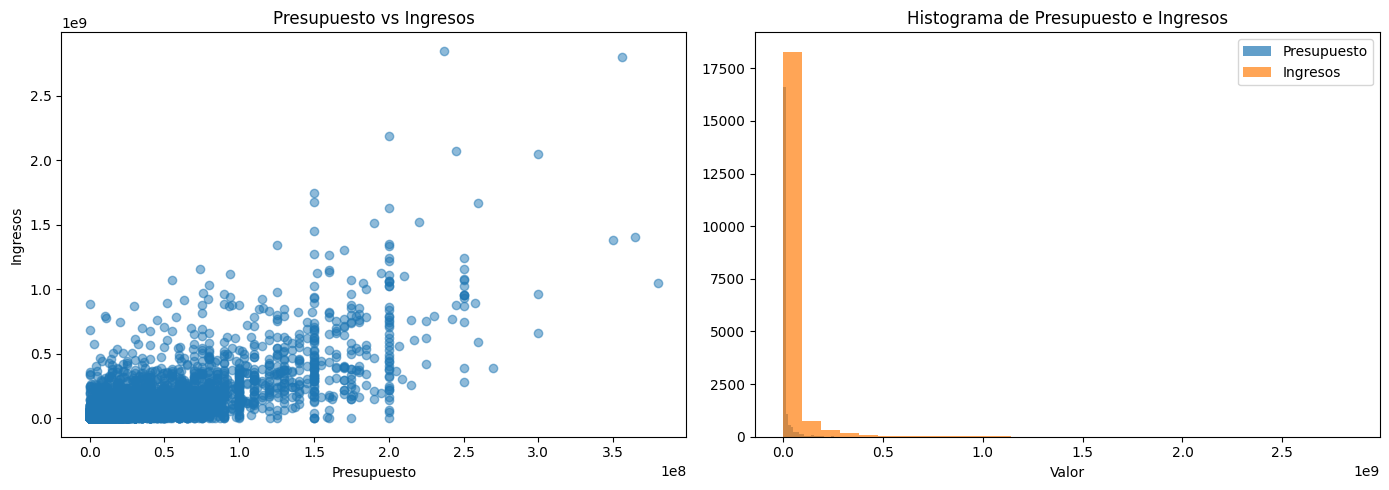

In [18]:
# correlacion de presupuestos con ingresos
# los altos presupuestos significan altos ingresos?
df11 = df[['budget', 'revenue']].copy()
df11 = df11.dropna()

# Crear la figura y los subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#diagrama de dispersión
axes[0].scatter(df11['budget'], df11['revenue'], alpha=0.5)
axes[0].set_title('Presupuesto vs Ingresos')
axes[0].set_xlabel('Presupuesto')
axes[0].set_ylabel('Ingresos')

# histograma
axes[1].hist(df11['budget'], bins=30, alpha=0.7, label='Presupuesto')
axes[1].hist(df11['revenue'], bins=30, alpha=0.7, label='Ingresos')
axes[1].set_title('Histograma de Presupuesto e Ingresos')
axes[1].set_xlabel('Valor')
axes[1].legend()

plt.tight_layout()
plt.show()

### Discusión de resultados 
Se nota una ligera correlación entre el presupuesto y los ingresos de las películas, principalmente en el grafico de dispersión ya que podemos notar que existe una leve tendencia a que a medida que el presupuesto va aumentando, los ingresos de la misma también aumentan. Sin embargo, esta correlación no es muy fuerte y existen muchos datos atípicos que pueden estar afectando la visualización de esta relación.

### 12. ¿Se asocian ciertos meses de lanzamiento con mejores ingresos?

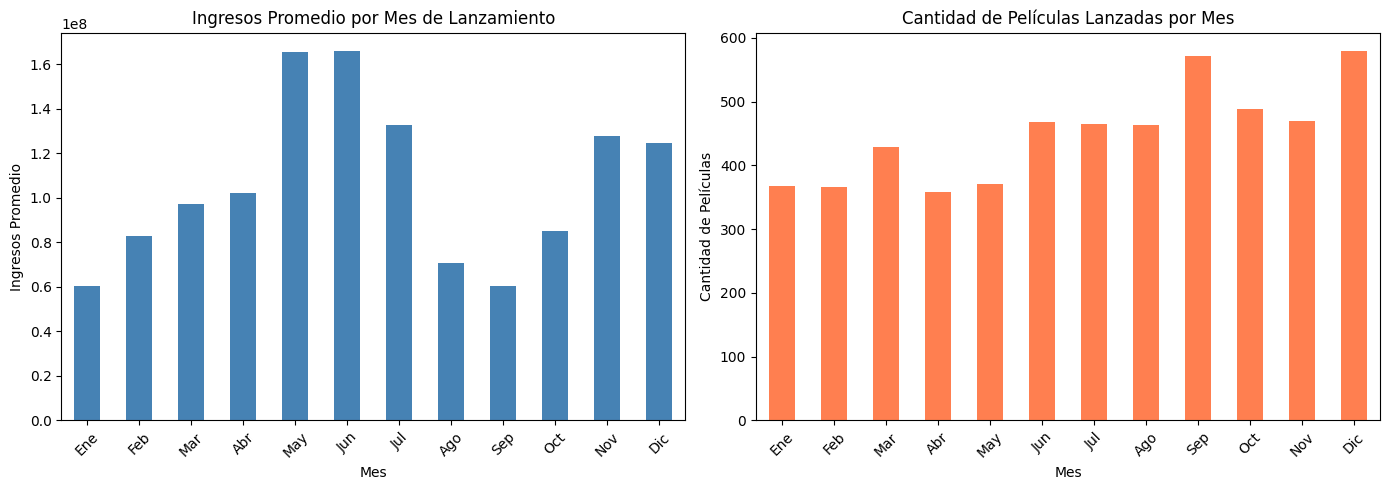


Resumen por Mes:
           Mes  Ingresos Promedio  Cantidad de Películas
0        Enero       6.040760e+07                    368
1      Febrero       8.276857e+07                    366
2        Marzo       9.710837e+07                    429
3        Abril       1.022529e+08                    358
4         Mayo       1.652726e+08                    371
5        Junio       1.658074e+08                    468
6        Julio       1.327641e+08                    465
7       Agosto       7.077733e+07                    464
8   Septiembre       6.033503e+07                    571
9      Octubre       8.514863e+07                    489
10   Noviembre       1.278116e+08                    470
11   Diciembre       1.244115e+08                    579


In [11]:
# asociación de meses de lanzamiento con mejores ingresos
df12 = df[['releaseDate', 'revenue']].copy()
df12 = df12.dropna()
df12 = df12[df12['revenue'] > 0]

df12['releaseDate'] = pd.to_datetime(df12['releaseDate'], errors='coerce')
df12 = df12.dropna(subset=['releaseDate'])
df12['release_month'] = df12['releaseDate'].dt.month

# Calcular ingresos promedio por mes
avg_revenue_by_month = df12.groupby('release_month')['revenue'].mean().sort_index()

# Contar películas por mes
movies_count_by_month = df12.groupby('release_month').size()

# Crear visualizaciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Ingresos promedio por mes
avg_revenue_by_month.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Ingresos Promedio por Mes de Lanzamiento')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Ingresos Promedio')
axes[0].set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
                          'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'], rotation=45)

# Gráfico 2: Cantidad de películas por mes
movies_count_by_month.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Cantidad de Películas Lanzadas por Mes')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Cantidad de Películas')
axes[1].set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
                          'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'], rotation=45)

plt.tight_layout()
plt.show()

# Mostrar tabla resumen
print("\nResumen por Mes:")
summary_table = pd.DataFrame({
    'Mes': ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 
            'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre'],
    'Ingresos Promedio': avg_revenue_by_month.values,
    'Cantidad de Películas': movies_count_by_month.values
})
print(summary_table)


### Discusión de resultados
Los resultados muestran que los meses con mejores ingresos totales son mayo, junio, julio, noviembre y diciembre. Esto podría deberse a que durante estos meses se lanzan muchas películas de gran presupuesto, como las películas de verano y las películas navideñas, que suelen atraer a un gran número de espectadores. Además, durante estos meses también se lanzan muchas películas de franquicias populares, lo que puede contribuir a los altos ingresos. Además son temporadas en la que las personas suelen tener vacaciones o tiempo libre, lo que aumenta la posibilidad de que vayan al cine. 

### 13. ¿En qué meses se han visto los lanzamientos con mejores ingresos?¿cuantas películas, en promedio, se han lanzado por mes?


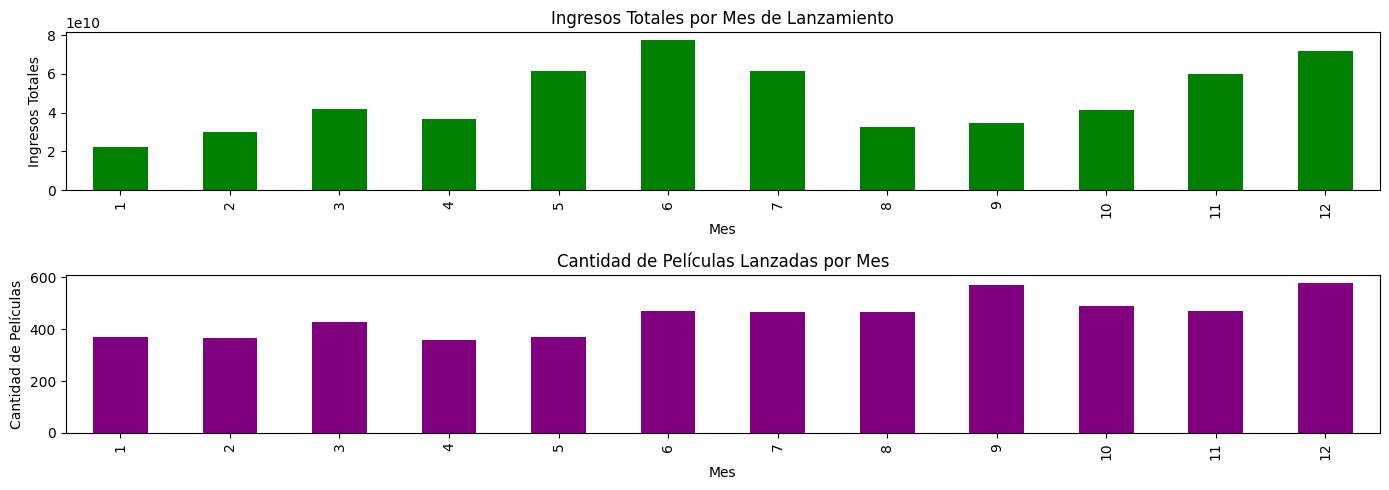

Promedio de películas lanzadas por mes: 449.83
Mes con mejores ingresos totales: Mes 6


In [13]:
total_revenue_by_month = df12.groupby('release_month')['revenue'].sum().sort_index()
avg_movies_by_month = df12['release_month'].value_counts().sort_index().mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 5))

#  Grafico ingresos totales por mes 
total_revenue_by_month.plot(kind='bar', ax=axes[0], color='green')
axes[0].set_title('Ingresos Totales por Mes de Lanzamiento')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Ingresos Totales')

# Gráfico de películas por mes
df12.groupby('release_month').size().plot(kind='bar', ax=axes[1], color='purple')
axes[1].set_title('Cantidad de Películas Lanzadas por Mes')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Cantidad de Películas')

plt.tight_layout()
plt.show()

print(f"Promedio de películas lanzadas por mes: {avg_movies_by_month:.2f}")
print(f"Mes con mejores ingresos totales: Mes {total_revenue_by_month.idxmax()}")

### Discusion Resultados
Los meses con lanzamientos con mejores ingresos son junio y diciembre. Aunque tambien podemos incluir a mayo, julio y noviembre. En cuanto al promedio o cantidad de peliculas lanzadas por mes, se observa que en diciembre y septiembre tienen el mayor número de lanzamientos, lo que podría estar relacionado con la temporada de vacaciones y festividades, lo que puede aumentar la demanda de entretenimiento. Sin embargo, es importante destacar que el número de lanzamientos no siempre se traduce en mayores ingresos, ya que otros factores como la calidad de las películas, la competencia en el mercado y las estrategias de marketing también juegan un papel crucial en el éxito comercial de las películas.

### 14. ¿Cómo se correlacionan las calificaciones con el éxito comercial?


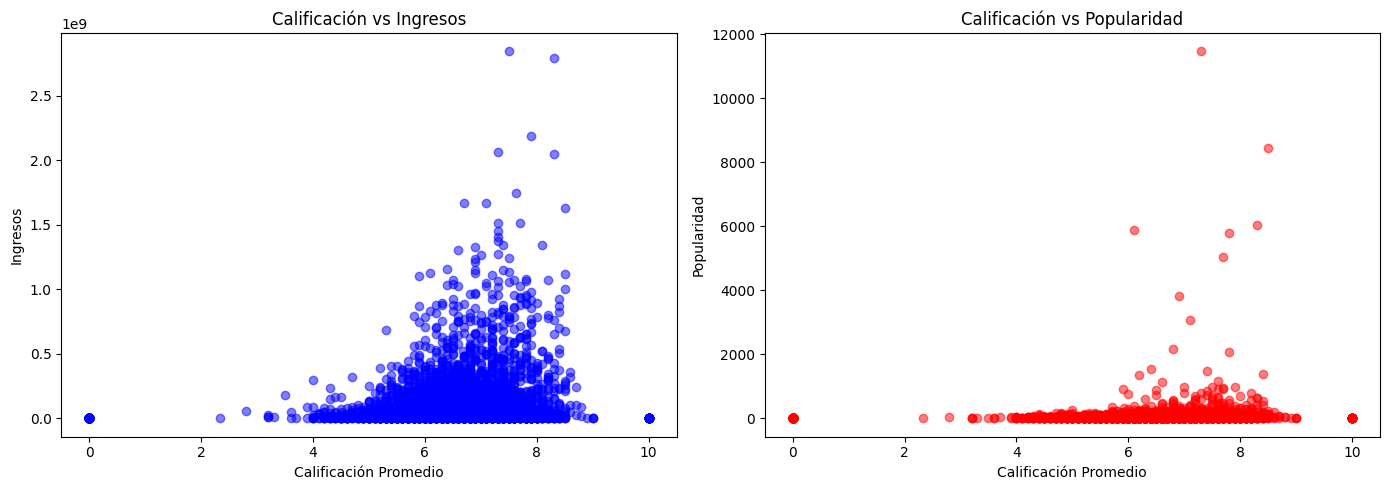

Correlación entre calificación e ingresos: 0.160
Correlación entre calificación y popularidad: 0.074


In [16]:
df14 = df[['voteAvg', 'revenue', 'popularity']].copy()
df14 = df14.dropna()
df14 = df14[df14['revenue'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calificación vs Ingresos
axes[0].scatter(df14['voteAvg'], df14['revenue'], alpha=0.5, color='blue')
axes[0].set_title('Calificación vs Ingresos')
axes[0].set_xlabel('Calificación Promedio')
axes[0].set_ylabel('Ingresos')

# Calificación vs Popularidad
axes[1].scatter(df14['voteAvg'], df14['popularity'], alpha=0.5, color='red')
axes[1].set_title('Calificación vs Popularidad')
axes[1].set_xlabel('Calificación Promedio')
axes[1].set_ylabel('Popularidad')

plt.tight_layout()
plt.show()

# Calcular correlación
correlacion_calif_ingresos = df14['voteAvg'].corr(df14['revenue'])
correlacion_calif_popularidad = df14['voteAvg'].corr(df14['popularity'])

print(f"Correlación entre calificación e ingresos: {correlacion_calif_ingresos:.3f}")
print(f"Correlación entre calificación y popularidad: {correlacion_calif_popularidad:.3f}")


### Discusion Resultados

No se observa una correlación clara entre las calificaciones y el éxito comercial de las películas. Aunque algunas películas con altas calificaciones también tienen altos ingresos, hay muchas excepciones a esta tendencia. Esto sugiere que otros factores, como el marketing, la popularidad del elenco, la competencia en el mercado y las preferencias del público, pueden tener un impacto significativo en el éxito comercial de una película, independientemente de su calidad percibida.

### 15. ¿La popularidad del elenco está directamente correlacionada con el éxito de taquilla?


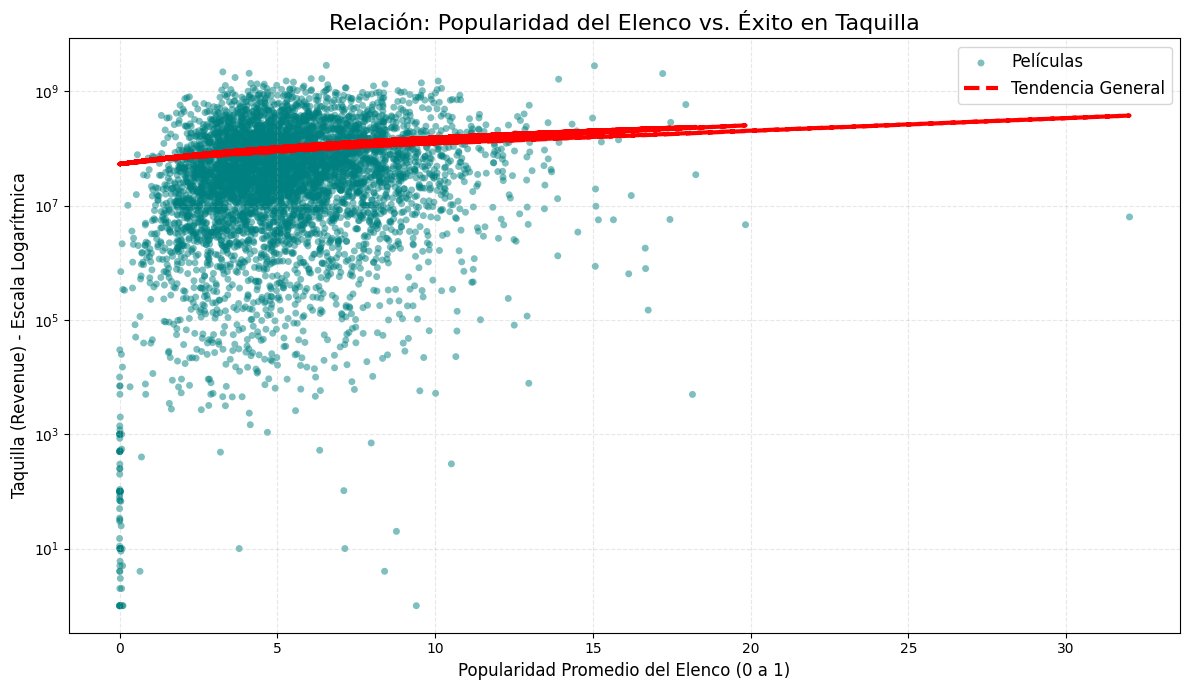

Coeficiente de Correlación: 0.1321


In [ ]:
# A. Convertir revenue a numérico
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

# B. Función para limpiar la popularidad (separar '|' y promediar)
def limpiar_y_promediar(val):
    if pd.isna(val) or val == '':
        return np.nan
    try:
        numeros = [float(x) for x in str(val).split('|') if x.strip()]
        return np.mean(numeros) if numeros else np.nan
    except (ValueError, AttributeError):
        return np.nan

# Aplicar la función
df['pop_promedio'] = df['actorsPopularity'].apply(limpiar_y_promediar)

# C. Filtrar datos sucios
df_clean = df.dropna(subset=['revenue', 'pop_promedio'])
df_clean = df_clean[(df_clean['pop_promedio'] > 0) & (df_clean['revenue'] > 0)]

plt.figure(figsize=(12, 7))

x = df_clean['pop_promedio']
y = df_clean['revenue']

# A. Dibujar los puntos (Scatter)
plt.scatter(x, y, alpha=0.5, c='teal', edgecolors='none', s=25, label='Películas')

# B. Dibujar Línea de Tendencia (Regresión Lineal)
if len(df_clean) > 1:
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    plt.plot(x, p(x), "r--", linewidth=3, label='Tendencia General')

# C. Configuración del Gráfico
plt.yscale('log') 
plt.title('Relación: Popularidad del Elenco vs. Éxito en Taquilla', fontsize=16)
plt.xlabel('Popularidad Promedio del Elenco (0 a 1)', fontsize=12)
plt.ylabel('Taquilla (Revenue) - Escala Logarítmica', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()


### Discusion de resultados

Podemos afirmar que sí existe una relación directa. Sin embargo, la popularidad del elenco no es una garantía absoluta de éxito, sino más bien un factor de reducción de riesgo.
Los datos sugieren que tener un elenco muy popular funciona como una 'red de seguridad': evita que las ganancias sean extremadamente bajas. Pero no asegura romper récords de taquilla.
De hecho, observamos casos atípicos en el rango de popularidad 15-20 que obtuvieron menos ingresos que muchas películas en el rango de 5-10, lo que demuestra que una película con popularidad media puede superar a una de 'estrellas' si otros factores influyen. Finalmente, es notable que la gran mayoría de las producciones se concentran en una popularidad promedio de 0 a 10, siendo los elencos de popularidad extrema casos excepcionales.

### 16. ¿Qué estrategias de marketing, como videos promocionales o páginas oficiales, generan mejores resultados?

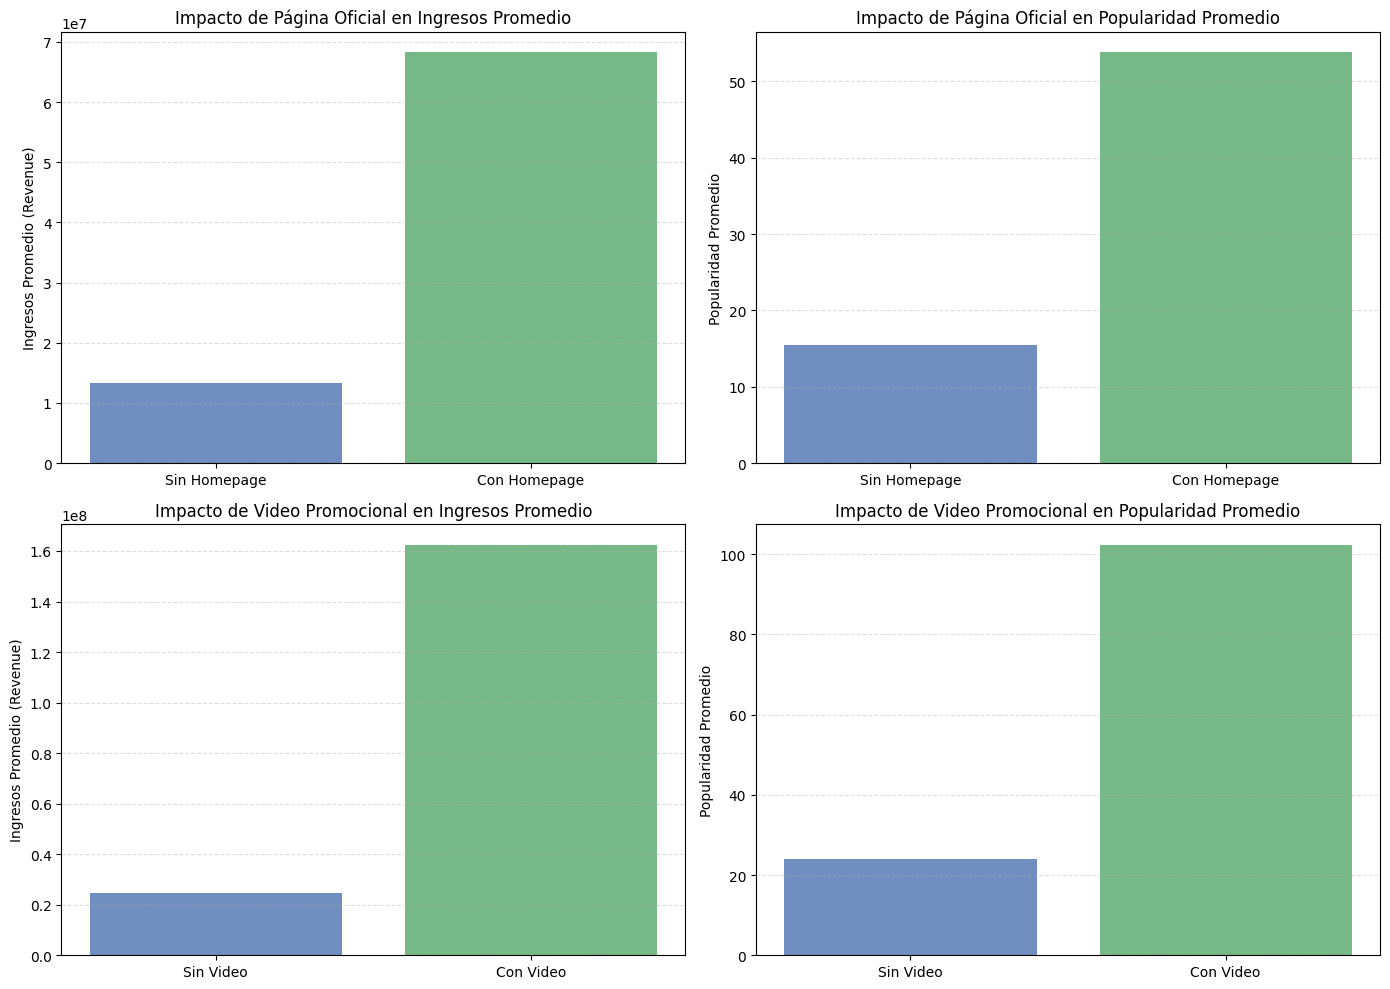

--- Impacto de Homepage ---
     Estrategia       revenue  popularity
0  Sin Homepage  1.329508e+07   15.427600
1  Con Homepage  6.824924e+07   53.800839

--- Impacto de Video ---
  Estrategia       revenue  popularity
0  Sin Video  2.484517e+07   24.001329
1  Con Video  1.625249e+08  102.400109


In [34]:
# 1. Preparar las variables de estrategia
if 'homePage' in df.columns:
    df['has_homepage'] = df['homePage'].apply(lambda x: 0 if pd.isnull(x) or x == '' else 1)
else:
    print("Advertencia: La columna 'homePage' no se encontró. Verifica el nombre exacto.")
    df['has_homepage'] = 0
if 'video' in df.columns:
    df['video_bool'] = df['video'].astype(bool).astype(int)
else:
    print("Advertencia: La columna 'video' no se encontró.")
    df['video_bool'] = 0

# 2. Análisis de Impacto de la Página Oficial (Homepage)
homepage_stats = df.groupby('has_homepage')[['revenue', 'popularity']].mean().reset_index()
homepage_stats['Estrategia'] = homepage_stats['has_homepage'].map({0: 'Sin Homepage', 1: 'Con Homepage'})

# 3. Análisis de Impacto del Video Promocional
video_stats = df.groupby('video_bool')[['revenue', 'popularity']].mean().reset_index()
video_stats['Estrategia'] = video_stats['video_bool'].map({0: 'Sin Video', 1: 'Con Video'})

# 4. Visualización
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colores = ['#4c72b0', '#55a868']
if not homepage_stats.empty:
    axes[0, 0].bar(homepage_stats['Estrategia'], homepage_stats['revenue'], color=colores, alpha=0.8)
axes[0, 0].set_title('Impacto de Página Oficial en Ingresos Promedio')
axes[0, 0].set_ylabel('Ingresos Promedio (Revenue)')
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.4)

if not homepage_stats.empty:
    axes[0, 1].bar(homepage_stats['Estrategia'], homepage_stats['popularity'], color=colores, alpha=0.8)
axes[0, 1].set_title('Impacto de Página Oficial en Popularidad Promedio')
axes[0, 1].set_ylabel('Popularidad Promedio')
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.4)

if len(video_stats) > 1:
    axes[1, 0].bar(video_stats['Estrategia'], video_stats['revenue'], color=colores, alpha=0.8)
    axes[1, 0].set_title('Impacto de Video Promocional en Ingresos Promedio')
    axes[1, 0].set_ylabel('Ingresos Promedio (Revenue)')
    axes[1, 0].grid(axis='y', linestyle='--', alpha=0.4)
else:
    axes[1, 0].text(0.5, 0.5, 'Datos de video insuficientes o sin variación', ha='center')

if len(video_stats) > 1:
    axes[1, 1].bar(video_stats['Estrategia'], video_stats['popularity'], color=colores, alpha=0.8)
    axes[1, 1].set_title('Impacto de Video Promocional en Popularidad Promedio')
    axes[1, 1].set_ylabel('Popularidad Promedio')
    axes[1, 1].grid(axis='y', linestyle='--', alpha=0.4)
else:
    axes[1, 1].text(0.5, 0.5, 'Datos de video insuficientes o sin variación', ha='center')
plt.tight_layout()
plt.show()

# Resumen numérico
print("--- Impacto de Homepage ---")
if not homepage_stats.empty:
    print(homepage_stats[['Estrategia', 'revenue', 'popularity']])
print("\n--- Impacto de Video ---")
if not video_stats.empty:
    print(video_stats[['Estrategia', 'revenue', 'popularity']])

### Discusion de resultados

Se puede ver que las producciones que invierten en activos como homepage o videos promocionales obtienen resultados que son mucho más superiores a las producciones que no tienen este tipo de promoción. Esto también se debe a que las producciones con alto presupuesto (que usualmente ganan más) son las que pueden costear estas campañas. Por lo que, si queremos que la producción alcance muchas ganancias, promocionarla es indiscutible. La estrategia del video suele ser una mejor forma de promocionar la producción que la página web sola.